## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Samuel Bromberg

**Date:** 9/29/2026

## Q1. Concept Review

1. **Regression vs. classification:** Regression predicts a number, like a house price or temperature. Classification predicts a category, like whether something is spam or not spam.

2. **Confusion table:** A confusion table compares the actual class to the model’s predicted class. It shows which categories the model gets right and which ones it often mixes up.

3. **SSE:** SSE, or sum of squared errors, adds up the squared differences between actual values and predicted values. A lower SSE means the predictions are closer to the real values, but low training SSE does not always mean the model will work well on new data.

4. **Overfitting and underfitting:** Overfitting happens when a model learns the training data too closely, including random noise, so it does poorly on new data. Underfitting happens when a model is too simple and cannot find the important patterns in the data.

5. **Train/test splitting and choosing `k`:** A test set should be saved for the end so it gives a fair estimate of how the model will perform on new data. We should choose `k` using the training data, usually with cross-validation, instead of repeatedly testing different values on the test set.

6. **Class label vs. probability distribution:** A class label gives one final prediction, while probabilities show how confident the model is in each possible class. Probabilities are more useful when the model is uncertain, but they should not be treated as guarantees.

First five rows:


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1



Mine type counts:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Summary of features:


,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000


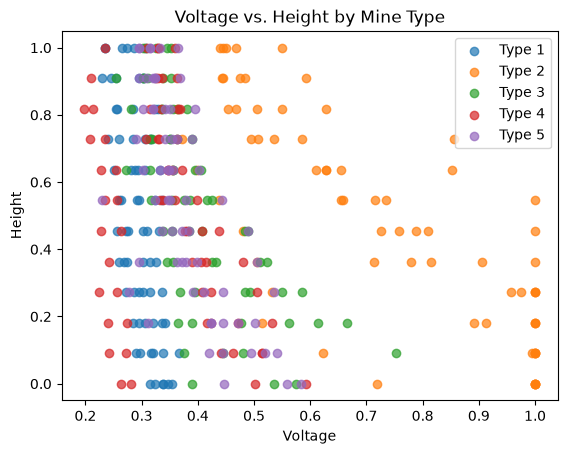


Training rows: 169
Testing rows: 169

Cross-validation scores:
k = 1 | average accuracy = 0.42
k = 3 | average accuracy = 0.396
k = 5 | average accuracy = 0.461
k = 7 | average accuracy = 0.479
k = 9 | average accuracy = 0.467
k = 11 | average accuracy = 0.42
k = 13 | average accuracy = 0.402
k = 15 | average accuracy = 0.396

Best k: 7

Test accuracy: 0.402

Confusion matrix:


,1,2,3,4,5
1,24,0,7,4,1
2,0,31,0,3,1
3,8,2,7,6,10
4,13,5,8,2,5
5,10,0,10,8,4


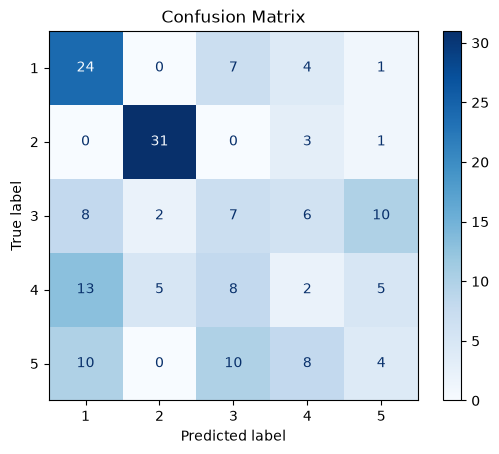


Number of incorrect predictions: 101

Most common mistakes:


count
actual predicted       
4      1             13
3      5             10
5      1             10
       3             10
3      1              8
4      3              8
5      4              8
1      3              7
3      4              6
4      2              5
       5              5
1      4              4
2      4              3
3      2              2
1      5              1
2      5              1

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


# Load the data
mines = pd.read_csv("data/land_mines.csv")

# Choose the columns used for prediction
features = ["voltage", "height", "soil"]
X = mines[features]
y = mines["mine_type"]

# Look at the dataset
print("First five rows:")
display(mines.head())

print("\nMine type counts:")
print(y.value_counts().sort_index())

print("\nSummary of features:")
display(X.describe())


# Graph voltage and height by mine type
for mine_type in sorted(y.unique()):
    group = mines[mines["mine_type"] == mine_type]

    plt.scatter(
        group["voltage"],
        group["height"],
        label=f"Type {mine_type}",
        alpha=0.7
    )

plt.title("Voltage vs. Height by Mine Type")
plt.xlabel("Voltage")
plt.ylabel("Height")
plt.legend()
plt.show()


# Split data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

print("\nTraining rows:", len(X_train))
print("Testing rows:", len(X_test))


# Try different k values using cross-validation
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
scores = []

for k in k_values:
    model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k)
    )

    cv_score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    scores.append(cv_score.mean())

# Print the average CV score for each k
print("\nCross-validation scores:")
for k, score in zip(k_values, scores):
    print("k =", k, "| average accuracy =", round(score, 3))

# Pick the k with the highest CV accuracy
best_k = k_values[scores.index(max(scores))]
print("\nBest k:", best_k)


# Train the final model with the best k
final_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=best_k)
)

final_model.fit(X_train, y_train)

# Make predictions on the test set
predictions = final_model.predict(X_test)


# Report final accuracy
test_accuracy = accuracy_score(y_test, predictions)
print("\nTest accuracy:", round(test_accuracy, 3))


# Create and display the confusion matrix
labels = sorted(y.unique())
matrix = confusion_matrix(y_test, predictions, labels=labels)

print("\nConfusion matrix:")
display(pd.DataFrame(
    matrix,
    index=labels,
    columns=labels
))

ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=labels
).plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()


# Show the rows where the model made mistakes
errors = pd.DataFrame({
    "actual": y_test,
    "predicted": predictions
})

errors = errors[errors["actual"] != errors["predicted"]]

print("\nNumber of incorrect predictions:", len(errors))

if len(errors) > 0:
    print("\nMost common mistakes:")
    display(errors.value_counts().rename("count").to_frame())
else:
    print("No incorrect predictions in this test split.")

The dataset contains 338 observations across five fairly balanced mine types. I used voltage, height, and soil to build a k-NN model, splitting the data evenly into training and test sets while keeping each mine type represented in both. I used five-fold cross-validation on the training data to choose `k = 7`.

The model had 40.2% accuracy on the test set. It predicted types 1 and 2 better than types 3, 4, and 5, which were often confused with other mine types. Because of these errors, this model should only be used as an extra tool to guide inspection, not to decide whether an area is safe or how to handle a mine.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]